<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 08.1

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time
from collections import Counter

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

/tmp/ipykernel_7944/1097861435.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


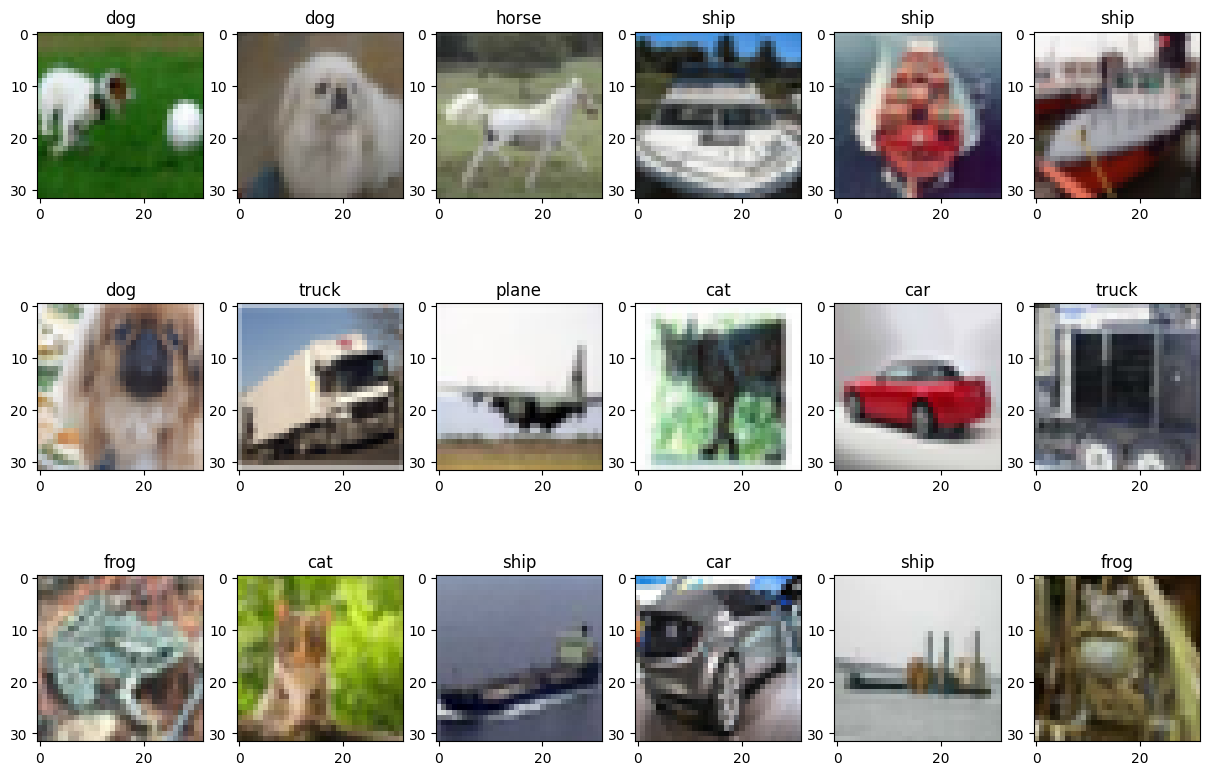

In [15]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

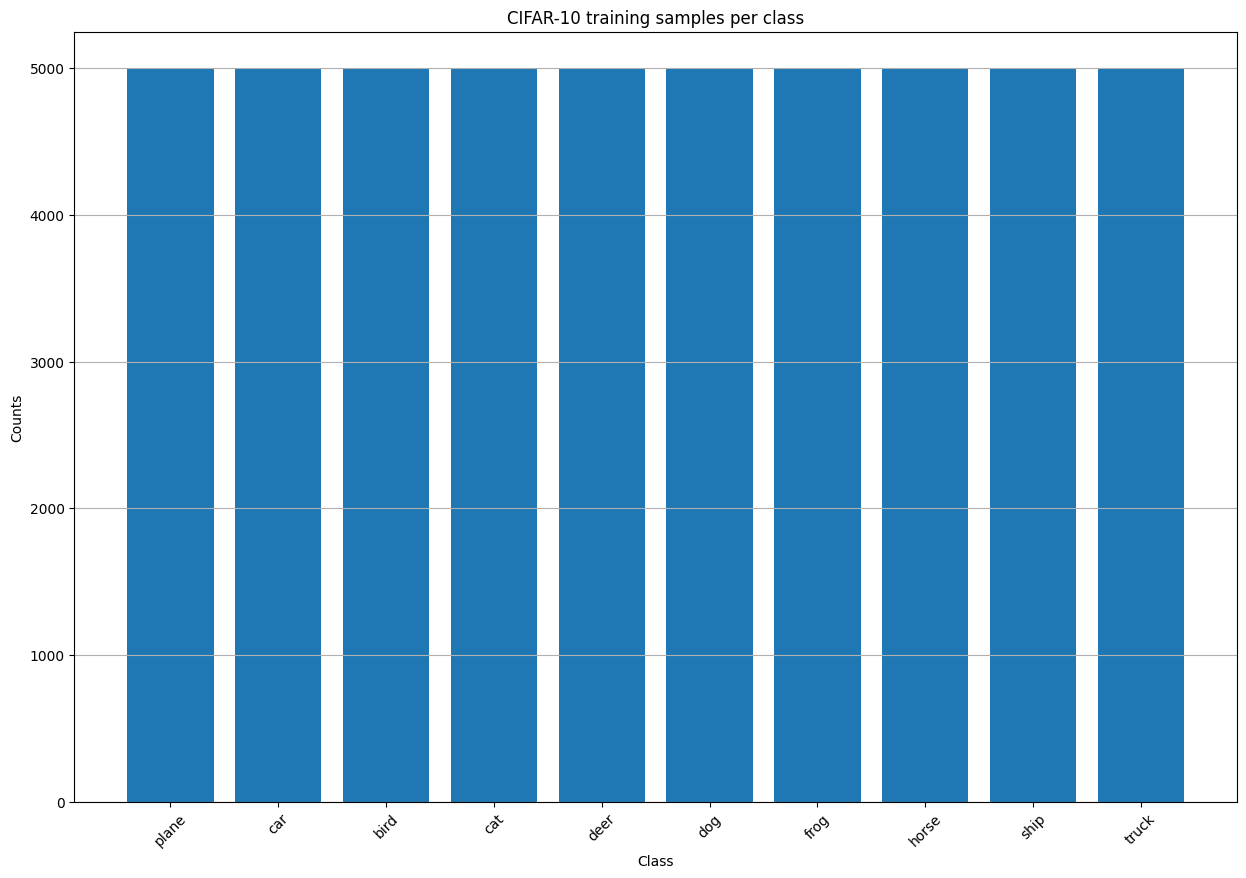

Counter({np.uint8(6): 5000, np.uint8(9): 5000, np.uint8(4): 5000, np.uint8(1): 5000, np.uint8(2): 5000, np.uint8(7): 5000, np.uint8(8): 5000, np.uint8(3): 5000, np.uint8(5): 5000, np.uint8(0): 5000})
Balanced: True


In [16]:
# Compute the class histogram
ids = y_train.flatten()
hist = Counter(ids)
class_ids = sorted(hist.keys())
counts = [hist[class_id] for class_id in class_ids]

plt.bar(class_ids, counts)
plt.xticks(class_ids, [classes[class_id] for class_id in class_ids], rotation=45)
plt.grid(True, axis='y')
plt.xlabel('Class')
plt.ylabel('Counts')
plt.title('CIFAR-10 training samples per class')
plt.show()

print(hist)
print('Balanced:', len(set(counts)) == 1)

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [17]:
# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [18]:
# Build the classifier
def build_classifier(use_augmentation=False):
    inputs = Input(shape=(size, size, 3))
    x = inputs

    if use_augmentation:
        x = tf.keras.Sequential([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomTranslation(0.1, 0.1),
            tf.keras.layers.RandomRotation(0.05),
        ], name='data_augmentation')(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs)


model =build_classifier(use_augmentation=False)

# Show the model
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [19]:
epochs = 25
batch_size = 128

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
start = time()
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2)
print('Training time:', round(time() - start, 2), 'seconds')

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 300ms/step - accuracy: 0.4237 - loss: 1.5940 - val_accuracy: 0.5325 - val_loss: 1.3278
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.5760 - loss: 1.1948 - val_accuracy: 0.6059 - val_loss: 1.1463
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.6489 - loss: 1.0080 - val_accuracy: 0.6562 - val_loss: 0.9901
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 295ms/step - accuracy: 0.6917 - loss: 0.8874 - val_accuracy: 0.6830 - val_loss: 0.9070
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 297ms/step - accuracy: 0.7224 - loss: 0.8004 - val_accuracy: 0.6951 - val_loss: 0.8845
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.7453 - loss: 0.7350 - val_accuracy: 0.6992 - val_loss: 0.8831
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.7669 - loss: 0.6691 - val_accuracy: 0.6990 - val_loss: 0.8973
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.7913 - loss:

Train Acc      0.9519249796867371
Validation Acc 0.6875


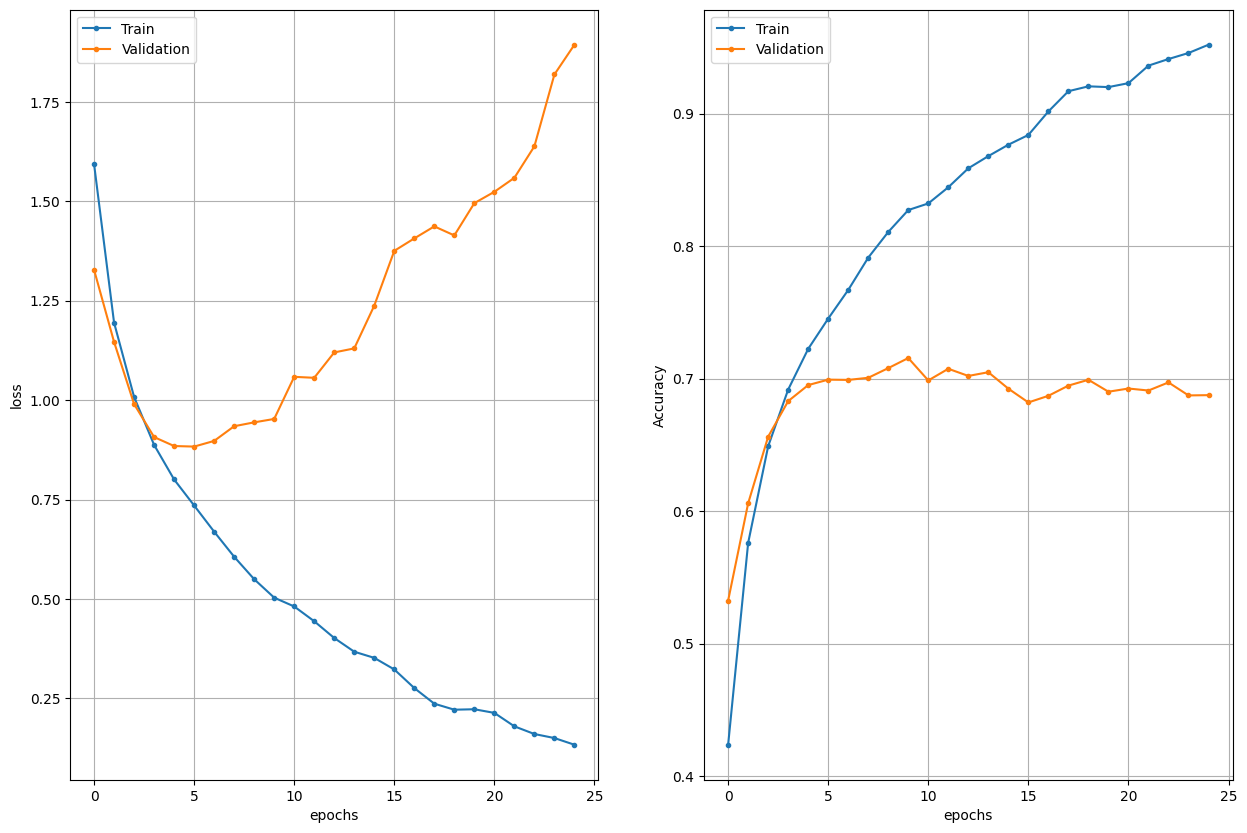

In [20]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [21]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test, batch_size=batch_size), axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step


In [22]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc = np.mean(y_pred[mask] == y_true[mask])
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(class_name, acc)

plane 0.823
car 0.758
bird 0.597
cat 0.534
deer 0.709
dog 0.379
frog 0.849
horse 0.696
ship 0.836
truck 0.714


In [23]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6895 - loss: 1.9055
Test loss   1.9054908752441406
Test metric 0.6894999742507935


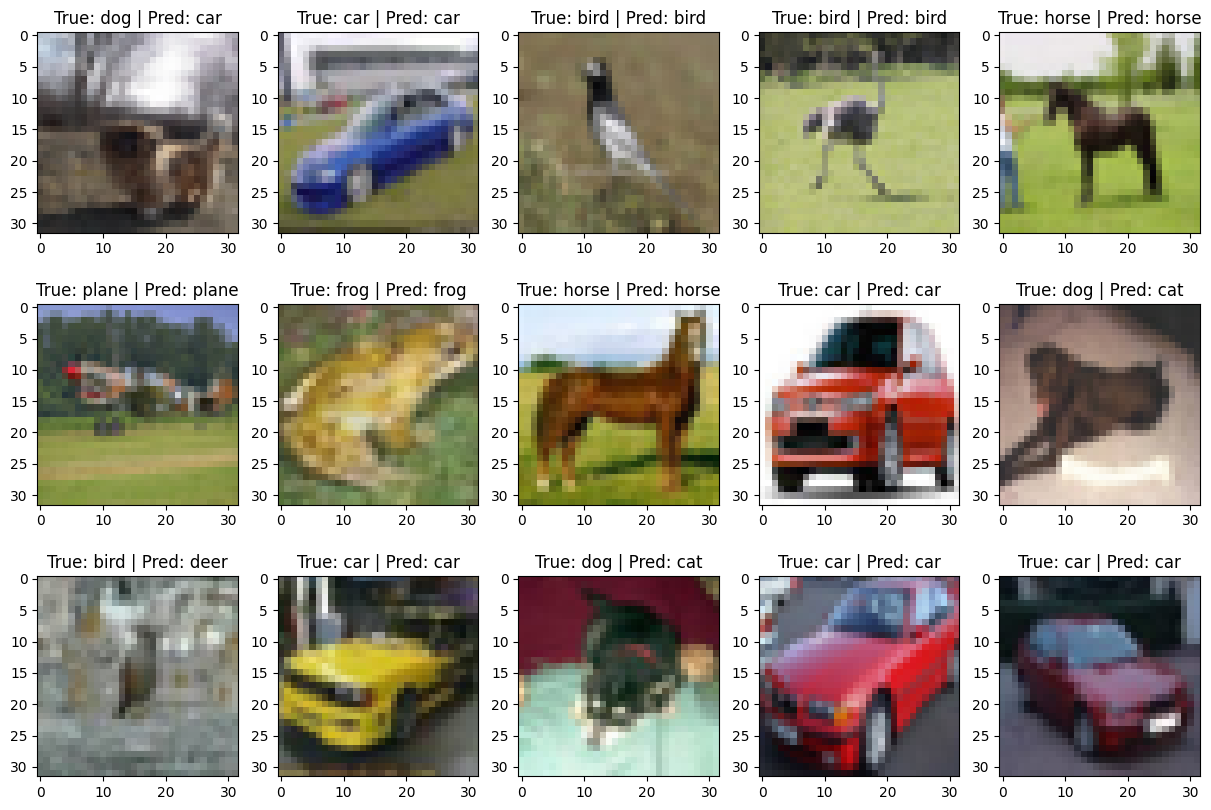

In [24]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

In [25]:
# One modification: add data augmentation
epochs = 25
batch_size = 128

set_seed(seed_value)
seed(seed_value)

aug_model = build_classifier(use_augmentation=True)

aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time()
aug_history = aug_model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

print('Training time with augmentation:', round(time() - start, 2), 'seconds')

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 325ms/step - accuracy: 0.3751 - loss: 1.7179 - val_accuracy: 0.4854 - val_loss: 1.4362
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.4959 - loss: 1.4023 - val_accuracy: 0.5670 - val_loss: 1.2276
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 338ms/step - accuracy: 0.5486 - loss: 1.2692 - val_accuracy: 0.5975 - val_loss: 1.1435
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 332ms/step - accuracy: 0.5854 - loss: 1.1745 - val_accuracy: 0.6331 - val_loss: 1.0685
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 335ms/step - accuracy: 0.6100 - loss: 1.1088 - val_accuracy: 0.6509 - val_loss: 1.0182
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 319ms/step - accuracy: 0.6334 - loss: 1.0453 - val_accuracy: 0.6739 - val_loss: 0.9592
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 335ms/step - accuracy: 0.6457 - loss: 1.0088 - val_accuracy: 0.6750 - val_loss: 0.9595
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 320ms/step - accuracy: 0.6577 -

In [28]:
aug_ev = aug_model.evaluate(x_test, y_test, batch_size=batch_size)

aug_test_loss = aug_ev[0]
aug_test_acc = aug_ev[1]

print('Baseline test accuracy:      ', ev[1])
print('Augmented model accuracy:    ', aug_test_acc)
print('Accuracy improved:           ', aug_test_acc >ev[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.7355 - loss: 0.8042
Baseline test accuracy:       0.6894999742507935
Augmented model accuracy:     0.7354999780654907
Accuracy improved:            True


### Questions
* What is the overall accuracy of the classifier?

The overall test accuracy of the classifier is about **69.7%**.

The printed test metric is:

`Test metric 0.6966999769210815`

* What modifications would you do in order to improve the classification accuracy?

To improve the classification accuracy, I would try adding **data augmentation**, **dropout**, and **batch normalization**. I would also consider using a deeper CNN, early stopping, and learning-rate scheduling.

The current model seems to overfit because the training accuracy is about **95.7%**, while the validation accuracy is only about **70.7%**. Therefore, regularization techniques such as data augmentation and dropout could help the model generalize better.

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

I would add **data augmentation** as one modification. For CIFAR-10, random horizontal flips, small translations, and small rotations can help because objects may appear in slightly different positions and orientations.

After training the classifier again with data augmentation, I would compare the new test accuracy with the original test accuracy of **69.7%**. If the new test accuracy is higher than **69.7%**, then the modification improved the classifier. If it is lower or similar, then the modification did not improve the result significantly.